In [1]:
#Assignment 2 YI
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn as sk
import matplotlib.pyplot as plt

# Загрузка данных:
Загрузите датасет и создайте DataFrame.
Установите правильные заголовки колонок.

In [2]:
data = pd.read_csv("heart.csv")

In [3]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
data.rename(columns = {'cp':'chest_pain', 'trestbps':'blood_pressure', 
                     'chol':'cholestoral', 'fbs':'blood sugar',
                    'restecg':'electrocardiography', 'thalach':'maxheartrate',
                    'exang':'exercise_angina'}, inplace = True )

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1025 non-null   int64  
 1   sex                  1025 non-null   int64  
 2   chest_pain           1025 non-null   int64  
 3   blood_pressure       1025 non-null   int64  
 4   cholestoral          1025 non-null   int64  
 5   blood sugar          1025 non-null   int64  
 6   electrocardiography  1025 non-null   int64  
 7   maxheartrate         1025 non-null   int64  
 8   exercise_angina      1025 non-null   int64  
 9   oldpeak              1025 non-null   float64
 10  slope                1025 non-null   int64  
 11  ca                   1025 non-null   int64  
 12  thal                 1025 non-null   int64  
 13  target               1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


# Предварительный обзор данных:
Просмотрите первые несколько строк данных.
Получите информацию о типах данных и пропущенных значениях.
Выполните статистический обзор данных.


In [6]:
data.head(10)

,age,sex,chest_pain,blood_pressure,cholestoral,blood sugar,electrocardiography,maxheartrate,exercise_angina,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1025 non-null   int64  
 1   sex                  1025 non-null   int64  
 2   chest_pain           1025 non-null   int64  
 3   blood_pressure       1025 non-null   int64  
 4   cholestoral          1025 non-null   int64  
 5   blood sugar          1025 non-null   int64  
 6   electrocardiography  1025 non-null   int64  
 7   maxheartrate         1025 non-null   int64  
 8   exercise_angina      1025 non-null   int64  
 9   oldpeak              1025 non-null   float64
 10  slope                1025 non-null   int64  
 11  ca                   1025 non-null   int64  
 12  thal                 1025 non-null   int64  
 13  target               1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
data.isnull().sum()

age                    0
sex                    0
chest_pain             0
blood_pressure         0
cholestoral            0
blood sugar            0
electrocardiography    0
maxheartrate           0
exercise_angina        0
oldpeak                0
slope                  0
ca                     0
thal                   0
target                 0
dtype: int64

In [9]:
data.describe() #use also info()

,age,sex,chest_pain,blood_pressure,cholestoral,blood sugar,electrocardiography,maxheartrate,exercise_angina,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
data.shape

(1025, 14)

In [11]:
data.corr()

,age,sex,chest_pain,blood_pressure,cholestoral,blood sugar,electrocardiography,maxheartrate,exercise_angina,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
chest_pain,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
blood_pressure,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
cholestoral,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
blood sugar,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
electrocardiography,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
maxheartrate,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exercise_angina,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


# Анализ пропущенных значений:
Определите количество и расположение пропущенных значений в датасете.
Решите, как будет осуществляться обработка пропущенных значений (замена, удаление и т.д.).


In [12]:
# data.fillna(df.mean(), inplace=True)

# Анализ распределения данных:
Постройте гистограммы распределения для количественных признаков.
Постройте коробчатые диаграммы для анализа выбросов и распределения.

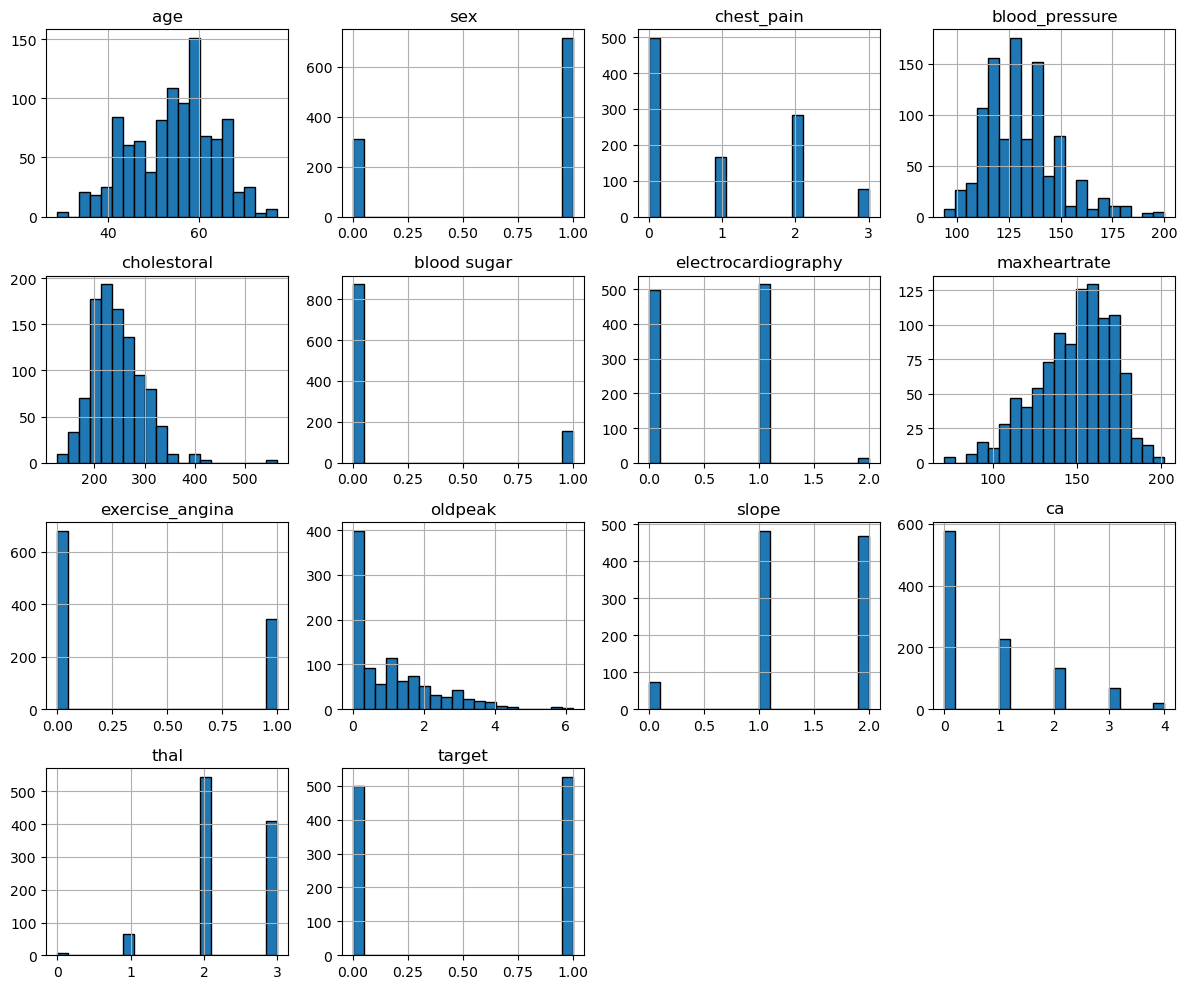

In [13]:
data.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

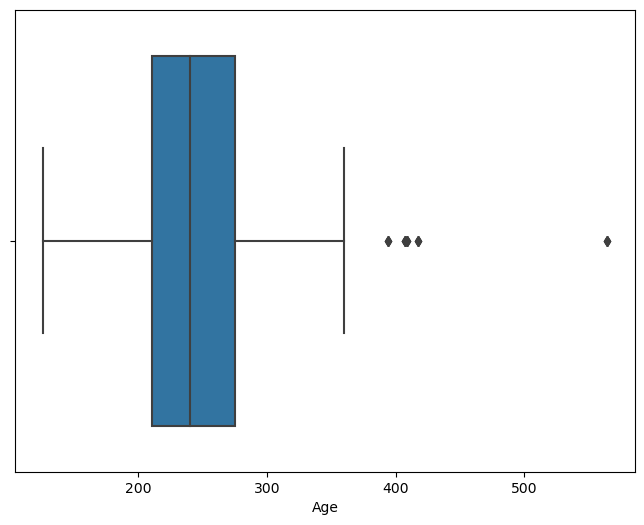

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['cholestoral'])
plt.xlabel('Age')
plt.show()

# Кодирование категориальных переменных:
Преобразуйте категориальные переменные в числовые с помощью подходящего кодирования (например, one-hot кодирование или кодирование целочисленными значениями).


# Обработка выбросов:
Выявите и проанализируйте выбросы в количественных данных.
Примите решение по поводу обработки выбросов (удаление, замена и т.д.).


# Нормализация данных:
Примените метод нормализации данных (например, Min-Max нормализацию или стандартное отклонение).
Убедитесь, что все числовые признаки приведены к одному масштабу.


In [23]:
"""""
from sklearn.preprocessing import StandardScaler

features = data.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
data[features] = scaler.fit_transform(data[features])
"""""

'""\nfrom sklearn.preprocessing import StandardScaler\n\nfeatures = data.select_dtypes(include=[\'float64\', \'int64\']).columns\nscaler = StandardScaler()\ndata[features] = scaler.fit_transform(data[features])\n'

# Разделение данных на обучающую и тестовую выборки:
Разделите данные на обучающую и тестовую выборки.
Определите пропорцию разделения (например, 70% для обучения и 30% для тестирования).


In [15]:
from sklearn.model_selection import train_test_split

X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)


# Анализ взаимосвязей между признаками:
Постройте корреляционную матрицу для количественных признаков.
Проанализируйте взаимосвязи между признаками и целевой переменной.


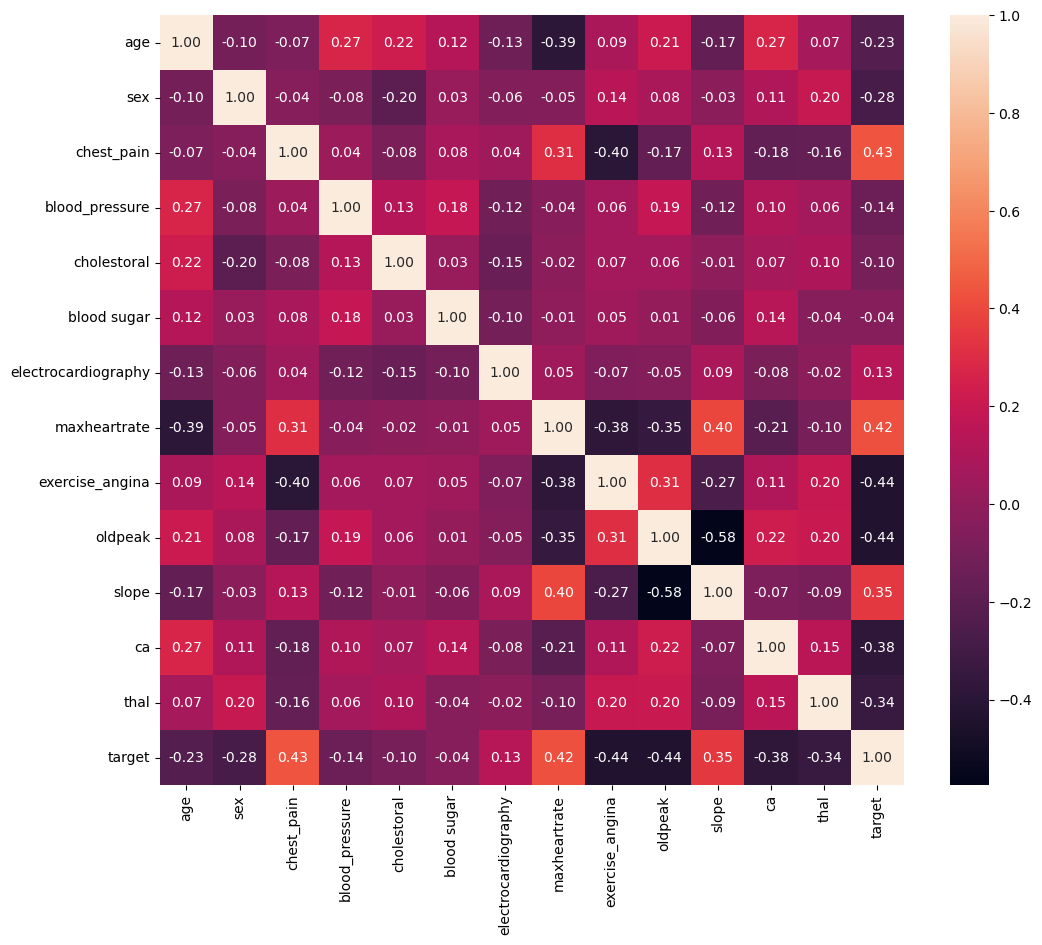

In [16]:
corr_matrix = data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.show()
#корреляционная зависимость — статистическая взаимосвязь двух или более случайных величин, 
#при которой изменения значений одной или нескольких из этих величин сопутствуют 
#систематическому изменению значений другой или других величин

# Подготовка данных для машинного обучения:
Подготовьте данные для использования в моделях машинного обучения, включая создание признаков и целевой переменной.
Обеспечьте, что данные готовы для обучения и тестирования моделей.


In [21]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


model = SVC()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(class_report)

Accuracy: 0.7012987012987013
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.55      0.66       164
           1       0.63      0.88      0.73       144

    accuracy                           0.70       308
   macro avg       0.73      0.71      0.70       308
weighted avg       0.74      0.70      0.69       308



In [22]:
print(y_train.unique())

[1 0]


# Обработка несбалансированных данных:
Проверьте, есть ли несбалансированность классов в целевой переменной.
Примените методы для балансировки данных, если это необходимо (например, увеличение выборки, уменьшение выборки и т.д.).
